In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-info"> 
    
# IX. Exercise: Putting it All Together

This exercise is in a separate file so that you can more easily reference the content in the Numpy and Pandas lessons if you need to by having multiple files open or side-by-side in Jupyter Lab.

In this exercise you will use NumPy (as well as Pandas and matplotlib) to read multiple csv files, create numpy arrays, execute calculations, and visualize results. The data files contain the Nino3.4 Index as well as monthly precipitation anomalies at 10 different US cities. Your task will be to get this data into NumPy arrays, calculate the mean precipitation anomaly at each city during El Nino and La Nina months, and visualize your calculations.

## 1) Intro to the El Nino Southern Oscillation (ENSO)
Start by watching this short video about the El Nino Southern Oscillation climate phenomenon and how it affects precipitation and temperature in the United States.

<video controls width="560" height="315" src="https://oceanservice.noaa.gov/facts/elninolanina/otkn_721_elninolanina_lg.mp4"></video>

As you saw in the video, ENSO is a feature of Earth's natural climate variability that impacts weather globally. It has 3 phases: El Nino (warm tropical Pacific), La Nina (cool tropical Pacific), and neutral (normal tropical Pacific). Over North America, the phase of ENSO modulates the location of the jet stream as well as the storm systems traveling along the jet stream. This results in areas of wetter/drier and cooler/warmer weather during El Nino and La Nina conditions. Weather impacts from El Nino and La Nina are generally strongest in winter months over North America. The strongest ENSO influence on US precipitation is seen in the southern US states from southern California to Florida. 

Scientists have developed a few different *indexes* for tracking the phase and strength of ENSO over time. The ENSO index we will use in this exercise is called the Nino3.4 Index. This index is created from monthly sea surface temperature anomalies (departure from the long term mean) from a region in the tropical Pacific ocean known as the Nino3.4 region. 

For the purposes of this exercise, we will select months with El Nino, La Nina, and neutral conditions with the following criteria:
- El Nino conditions - months when the Index is greater than +1,
- La Nina conditions - months when the Index is less than -1, and
- neutral conditions - months when the Index is between -0.25 and +0.25
  
The way research scientists identify El Nino and La Nina events from the Nino3.4 Index is little bit more complex. We won't get into the details here though since this exercise is focused on NumPy practice, not scientific rigor.

<div class="alert alert-info"> 

## 2) Read the Nino3.4 Index Data File and Convert to Array
Read the file at ```data/NOAA_ClimateIndex/Nino34ClimateIndex.txt``` into a Pandas DataFrame called ```enso``` and render the DataFrame to the screen. (This is the same file we read in the NumPy notebook)
</div>

In [2]:
# base period for these anomalies is 1991-2020
enso = pd.read_csv(r'data/NOAA_ClimateIndex/Nino34ClimateIndex.txt',
                   header=None,
                   skiprows=1,
                   skipfooter=3,
                   na_values=-99.99,
                   delimiter=r'\s+',
                   names=np.arange(1,13),
                   engine='python')
enso

,1,2,3,4,5,6,7,8,9,10,11,12
1948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950,-1.99,-1.69,-1.42,-1.54,-1.75,-1.27,-1.01,-0.97,-0.98,-1.03,-1.23,-1.31
1951,-1.30,-1.04,-0.38,-0.23,-0.01,0.00,0.30,0.17,0.51,0.49,0.55,0.31
1952,0.13,-0.01,-0.11,-0.02,-0.14,-0.54,-0.76,-0.56,-0.36,-0.46,-0.78,-0.39
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,-1.00,-1.00,-0.80,-0.72,-0.46,-0.28,-0.39,-0.53,-0.55,-0.94,-0.94,-1.06
2022,-0.94,-0.89,-0.97,-1.11,-1.11,-0.75,-0.69,-0.97,-1.07,-0.99,-0.90,-0.85
2023,-0.72,-0.46,-0.11,0.14,0.46,0.84,1.02,1.35,1.60,1.72,2.02,2.03
2024,1.81,1.52,1.13,0.77,0.23,0.17,0.04,-0.12,-0.26,-0.27,-0.25,-0.60


<div class="alert alert-info"> 

Drop all rows from the dataframe that contain any NaN and verify programmatically that there are no NaN remaining in the dataframe.
</div>

In [3]:
enso = enso.dropna(how='any')
enso.isna().sum()

1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
dtype: int64

<div class="alert alert-info"> 

Convert the ```enso``` DataFrame to a 1D Numpy array called ```enso_arr``` where the values of the Nino3.4 index are sequential in time. Render the first 13 values of the array to the screen.

Hint: Reference the following sections in the NumPy lesson for the functions you will need:
- Converting between Pandas and NumPy Data Structures
- Removing and Collapsing Dimensions
</div>

In [4]:
enso_arr = enso.to_numpy().flatten()
enso_arr[0:13]

array([-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98,
       -1.03, -1.23, -1.31, -1.3 ])

<div class="alert alert-info"> 

Just for extra practice, use NumPy functions to count how many total NaNs there are in ```enso_arr```.

</div>

In [11]:
print(np.isnan(enso_arr).sum())

0


<div class="alert alert-info"> 

Plot the Nino3.4 timeseries (```enso_arr```) with matplotlib.pyplot (```plt```). Include the following:
- stretch your figure width using figsize=(10,2)
- create a pandas index of datetime objects and use them for the x values
- include a grey dashed reference line at y=0
- include a title

</div>

In [31]:
dates= pd.date_range('1950-01','2024-12',freq='MS')
dates

DatetimeIndex(['1950-01-01', '1950-02-01', '1950-03-01', '1950-04-01',
               '1950-05-01', '1950-06-01', '1950-07-01', '1950-08-01',
               '1950-09-01', '1950-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', length=900, freq='MS')

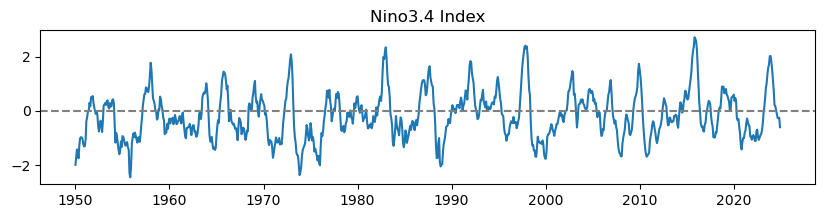

In [40]:
fig = plt.figure(figsize=(10,2))
plt.plot(dates,enso_arr)
plt.axhline(0,color='grey',ls='dashed')
plt.title('Nino3.4 Index')
plt.show()

<div class="alert alert-info"> 

## 3) Read the Precipitation Data Files

The monthly precipitation anomalies are provided in two separate files for your *in*convenience so you can practice combining data from multiple files. The two files are: 

- ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv```
- ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv```

Each row of data in these files contain the following information: the city name, latitude, longitude, precipitation units, base period used to create the anomalies, link to the original data source, data access date, and monthly precipitation anomaly values.  

There are multiple ways to get the precipitation anomalies from these two files into a single NumPy array. The next steps will guide you through one method that allows you to practice using both Pandas and NumPy functions.

Read the file at ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv``` into a Pandas dataframe called ```df1``` and render the head to the screen.
</div>

In [6]:
df1 = pd.read_csv('data/nclimgrid/pr_anomaly_nclimgrid_monthly_8cities.csv')
df1.head()

,CITY,LATITUDE,LONGITUDE,UNITS,BASE,SOURCE,ACCESSED,1950-01-01 00:00:00,1950-02-01 00:00:00,1950-03-01 00:00:00,...,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00
0,San Diego,32.812534,-117.145836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,24.260742,-29.877510,-15.437077,...,33.333430,-11.200521,-3.815039,-1.198763,-0.830371,0.568099,-3.070801,-13.003613,-18.404720,-44.571907
1,Tucson,32.187534,-110.895836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-19.914062,8.528027,-12.281836,...,15.957422,11.647949,-4.493327,15.638867,9.600422,-15.562370,-24.553972,-16.139616,-2.849024,-29.774350
2,El Paso,31.770866,-106.479164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-2.001856,-4.027083,-5.530696,...,-4.580501,-3.317741,-7.582292,-4.118620,-10.607456,-26.614616,-28.582650,-15.280859,10.365202,-14.309668
3,Austin,30.270866,-97.729164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-44.206543,42.778973,-48.979850,...,-23.460320,14.113670,11.750687,-33.024544,54.006542,-29.506771,-77.203810,-105.855630,-20.089775,-29.711357
4,Houston,29.770866,-95.354164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,2.015236,63.515656,-67.185450,...,-3.505760,-1.802376,103.618484,-19.365753,249.633670,-87.673280,-85.412110,-103.408690,-17.276726,-20.919952


<div class="alert alert-info"> 

What is the year and month of the first column of precipitation anomalies in this file? Does this match the starting year and month of your ```enso_arr``` data? 
</div>

1950-01, yes

<div class="alert alert-info"> 

Create a 2D NumPy array called ```pr``` of the precipitation anomalies in ```df1``` where the first dimension represents the location and the second dimension represents the dates (i.e., the shape of your array should be (8,900))
</div>

In [7]:
pr = df1.loc[:,'1950-01-01 00:00:00':].to_numpy()
pr.shape

(8, 900)

<div class="alert alert-info"> 

Read the file at ```data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv``` into a Pandas dataframe called ```df2``` and render the head to the screen.
</div>

In [8]:
df2 = pd.read_csv('data/nclimgrid/pr_anomaly_nclimgrid_monthly_2cities.csv')
df2.head()

,CITY,LATITUDE,LONGITUDE,UNITS,BASE,SOURCE,ACCESSED,1949-01-01 00:00:00,1949-02-01 00:00:00,1949-03-01 00:00:00,...,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00
0,Jacksonville,30.312532,-81.645836,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-54.618004,58.635582,-62.41195,...,61.688637,-27.230309,-10.912697,-94.11972,53.336746,111.819824,138.871610,-32.89235,-30.605210,-32.650032
1,Orlando,28.479200,-81.354164,mm,1991-2020,https://www.ncei.noaa.gov/access/metadata/land...,MARCH 2025,-58.896027,-37.726433,-59.68490,...,-38.394860,-30.413345,-37.702835,-36.02507,-38.789460,30.451310,20.322983,87.21250,-21.253971,-24.752995


<div class="alert alert-info"> 

What is the year and month of the first column of precipitation anomalies in this file? Does this match the starting year and month of your ```enso_arr``` data? 
</div>

1949-01, no

<div class="alert alert-info"> 

Create a 2D NumPy array called ```more_pr``` of the precipitation anomalies in ```df2``` where the first dimension represents the location and the second dimension represents the dates (i.e., the shape of your array should be (2,900))
</div>

In [9]:
more_pr = df2.loc[:,'1950-01-01 00:00:00':].to_numpy()
more_pr.shape

(2, 900)

<div class="alert alert-info"> 

Concatenate the ```pr``` and ```more_pr``` arrays together. Continue using the variable name ```pr``` for the final combined data. Verify that your new pr array has the shape (10,900)
</div>

In [10]:
pr = np.concatenate([pr,more_pr])
pr.shape

(10, 900)

<div class="alert alert-info"> 
    
Count how many NaNs there are in ```pr```.
</div>

In [14]:
print(np.isnan(pr).sum())

0


## 4) Use Advanced Indexing to Find Mean Precipitation Anomalies during El Nino and La Nina Months